# Multimodal Human Activity Recognition on Adapted MHEALTH
**Assignment 2 | Sensor Fusion & Activity Classification**
**Author:** Satya Siddhartha Balanagu (Student ID: A1961325)  
**Institution:** School of Computer Science, University of Adelaide  

This notebook implements an end-to-end multimodal machine learning pipeline on the adapted MHEALTH dataset (Banos et al., 2014; UCI ML Repository).
It covers:
1. **Task 1: Data Exploration (EDA)** — Data loading, structural verification, kinetic energy distributions, and cross-sensor correlation analysis.
2. **Task 2: Missing Data & Preprocessing** — Audit of 615,648 missing values (7.80%), burst length analysis, segment-bounded intra-run linear interpolation (strictly avoiding cross-activity leakage), sliding window segmentation (128 samples / 2.56s, 50% overlap), and domain feature extraction (53 features per sensor).
3. **Task 3: Multimodal Fusion & Modelling** — Subject-independent train/val/test partitioning (Train: Subs 1-7, Val: Sub 8, Test: Subs 9-10). Selection of 3 sensor sources across 2 modalities (Chest Accel, Ankle Accel, Wrist Gyro). Implementation and training of 3 Unimodal Baselines and 2 Multimodal Fusion models (Early Concatenation & Late Soft-Voting Ensemble) with AdamW, Cosine Annealing, and validation Macro-F1 checkpointing.
4. **Task 4: Evaluation, Critical Discussion & Ethics** — Test set evaluation, normalized confusion matrices, multi-class ROC & PR curves, comprehensive per-class F1 breakdown for all 5 models, latency and computational trade-off analysis, and regulatory/ethical governance.


In [1]:
# Environment setup, imports, and reproducibility seed
import os, glob, time, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.fft import rfft, rfftfreq

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'PyTorch Device: {DEVICE}, Seed: {SEED}')


PyTorch Device: mps, Seed: 42


## Task 1: Data Exploration and Preprocessing
The MHEALTH dataset collects 23 sensor channels across 3 Shimmer2 units (Chest, Left Ankle, Right Wrist) at 50 Hz.
In this adapted version, the null activity (class 0) has been removed, leaving exactly 12 structured activities.


In [2]:
DATA_DIR = 'MHEALTHDATASET_MISSING'
files = sorted(glob.glob(os.path.join(DATA_DIR, 'mHealth_subject*.log')))
print(f'Found {len(files)} subject log files in {DATA_DIR}.')

COLUMN_NAMES = [
    'chest_acc_x', 'chest_acc_y', 'chest_acc_z',
    'chest_ecg_1', 'chest_ecg_2',
    'ankle_acc_x', 'ankle_acc_y', 'ankle_acc_z',
    'ankle_gyr_x', 'ankle_gyr_y', 'ankle_gyr_z',
    'ankle_mag_x', 'ankle_mag_y', 'ankle_mag_z',
    'wrist_acc_x', 'wrist_acc_y', 'wrist_acc_z',
    'wrist_gyr_x', 'wrist_gyr_y', 'wrist_gyr_z',
    'wrist_mag_x', 'wrist_mag_y', 'wrist_mag_z',
    'activity'
]

raw_dfs = {}
total_rows = 0
for f in files:
    sub_id = int(os.path.basename(f).replace('mHealth_subject', '').replace('.log', ''))
    df = pd.read_csv(f, sep=r'\s+', header=None)
    df.columns = COLUMN_NAMES
    df['subject'] = sub_id
    raw_dfs[sub_id] = df
    total_rows += len(df)

print(f'Total dataset records: {total_rows:,} samples across 10 participants.')


Found 10 subject log files in MHEALTHDATASET_MISSING.


Total dataset records: 343,195 samples across 10 participants.


## Task 2: Missing Data Audit & Leakage-Free Preprocessing
We audit missingness across all sensor channels and consecutive burst lengths.
Interpolation is strictly confined within continuous activity runs for each participant.


In [3]:
# Audit missing values and run segment-bounded interpolation
cleaned_dfs = {}
total_nans = 0

for sub_id, df in raw_dfs.items():
    total_nans += df.iloc[:, :23].isna().sum().sum()
    changes = (df['activity'] != df['activity'].shift()).cumsum()
    cleaned_runs = []
    for run_id, grp in df.groupby(changes):
        interp = grp.iloc[:, :23].interpolate(method='linear', limit_direction='both')
        grp_clean = pd.concat([interp, grp[['activity', 'subject']]], axis=1)
        cleaned_runs.append(grp_clean)
    cleaned_df = pd.concat(cleaned_runs, ignore_index=True)
    assert cleaned_df.iloc[:, :23].isna().sum().sum() == 0, f'Residual NaNs in Subject {sub_id}'
    cleaned_dfs[sub_id] = cleaned_df

print(f'Total NaNs audited: {total_nans:,} (7.80% of sensor stream).')
print('Intra-segment interpolation complete. Residual missing values across all subjects: 0.')


Total NaNs audited: 615,648 (7.80% of sensor stream).
Intra-segment interpolation complete. Residual missing values across all subjects: 0.


### Sliding Window Segmentation & Feature Extraction
Window length: 128 samples (2.56s at 50 Hz), 50% overlap (64 samples).
Extracts 53 time- and frequency-domain features per 3-axis sensor stream.


In [4]:
from run_experiments import extract_sensor_features, build_windowed_dataset

records = build_windowed_dataset(cleaned_dfs, window_size=128, step_size=64)
print(f'Total segmented windows: {len(records)}')


Using device: mps
Segmenting time windows and extracting features...


Extracted 5229 windows in 18.92 seconds.
Total segmented windows: 5229


## Task 3: Multimodal Fusion & Experimental Comparison
We train 3 Unimodal Baselines (Chest Accel, Ankle Accel, Wrist Gyro) and 2 Multimodal Fusion models (Early Concatenation & Late Soft-Voting).
Train: Subjects 1-7; Val: Subject 8; Test: Subjects 9-10.


In [5]:
from run_experiments import run_all_experiments, plot_evaluation_figures

(
    all_models, histories, best_epochs, metrics_summary,
    per_class_summary, y_test, probs_chest, probs_ankle, probs_wrist, probs_early, probs_late
) = run_all_experiments(records)


Dataset Partitions (Subject-Independent):
  Train Set (Subs [1, 2, 3, 4, 5, 6, 7]): 3686 windows
  Val Set   (Subs [8]):   508 windows
  Test Set  (Subs [9, 10]):  1035 windows

--- Training Model 1: Unimodal Chest Accelerometer ---


Loaded best checkpoint from Epoch 16 with Val Macro-F1: 0.7537

--- Training Model 2: Unimodal Ankle Accelerometer ---


Loaded best checkpoint from Epoch 19 with Val Macro-F1: 0.8370

--- Training Model 3: Unimodal Wrist Gyroscope ---


Loaded best checkpoint from Epoch 11 with Val Macro-F1: 0.5235

--- Training Model 4: Multimodal Early Fusion (Concatenation) ---


Loaded best checkpoint from Epoch 18 with Val Macro-F1: 0.8643

Late Fusion Weights: Chest=0.356, Ankle=0.396, Wrist=0.248


## Task 4: Evaluation and Critical Discussion
We examine the comparative performance of all models on the test set (Subjects 9 and 10).


In [6]:
df_metrics = pd.DataFrame(metrics_summary)
print('--- Overall Model Evaluation Summary ---')
print(df_metrics.to_string(index=False))

df_per_class = pd.DataFrame(per_class_summary)
from run_experiments import ACTIVITY_NAMES
df_per_class.index = [ACTIVITY_NAMES[i] for i in range(1, 13)]
print()
print('--- Per-Class F1 Score Breakdown Across All 5 Models ---')
print(df_per_class.to_string())


--- Overall Model Evaluation Summary ---
       model  accuracy  macro_precision  macro_recall  macro_f1  weighted_f1  parameters  latency_ms selected_epoch
 Chest Accel    0.8918           0.9293        0.9007    0.8948       0.8854       16332       0.037             16
 Ankle Accel    0.8589           0.8913        0.8649    0.8641       0.8588       16332       0.036             19
  Wrist Gyro    0.8560           0.8836        0.8259    0.8253       0.8456       16332       0.037             11
Early Fusion    0.9536           0.9712        0.9574    0.9546       0.9506       76172       0.038             18
 Late Fusion    0.9536           0.9713        0.9574    0.9547       0.9506       48996       0.115              -

--- Per-Class F1 Score Breakdown Across All 5 Models ---
                           Chest Accel  Ankle Accel  Wrist Gyro  Early Fusion  Late Fusion
Standing still                0.788136     0.658635    0.880383      0.800000     0.800000
Sitting & relaxing     

### Visual Inspection of Generated Figures
Displaying confusion matrices and ROC / PR curves.


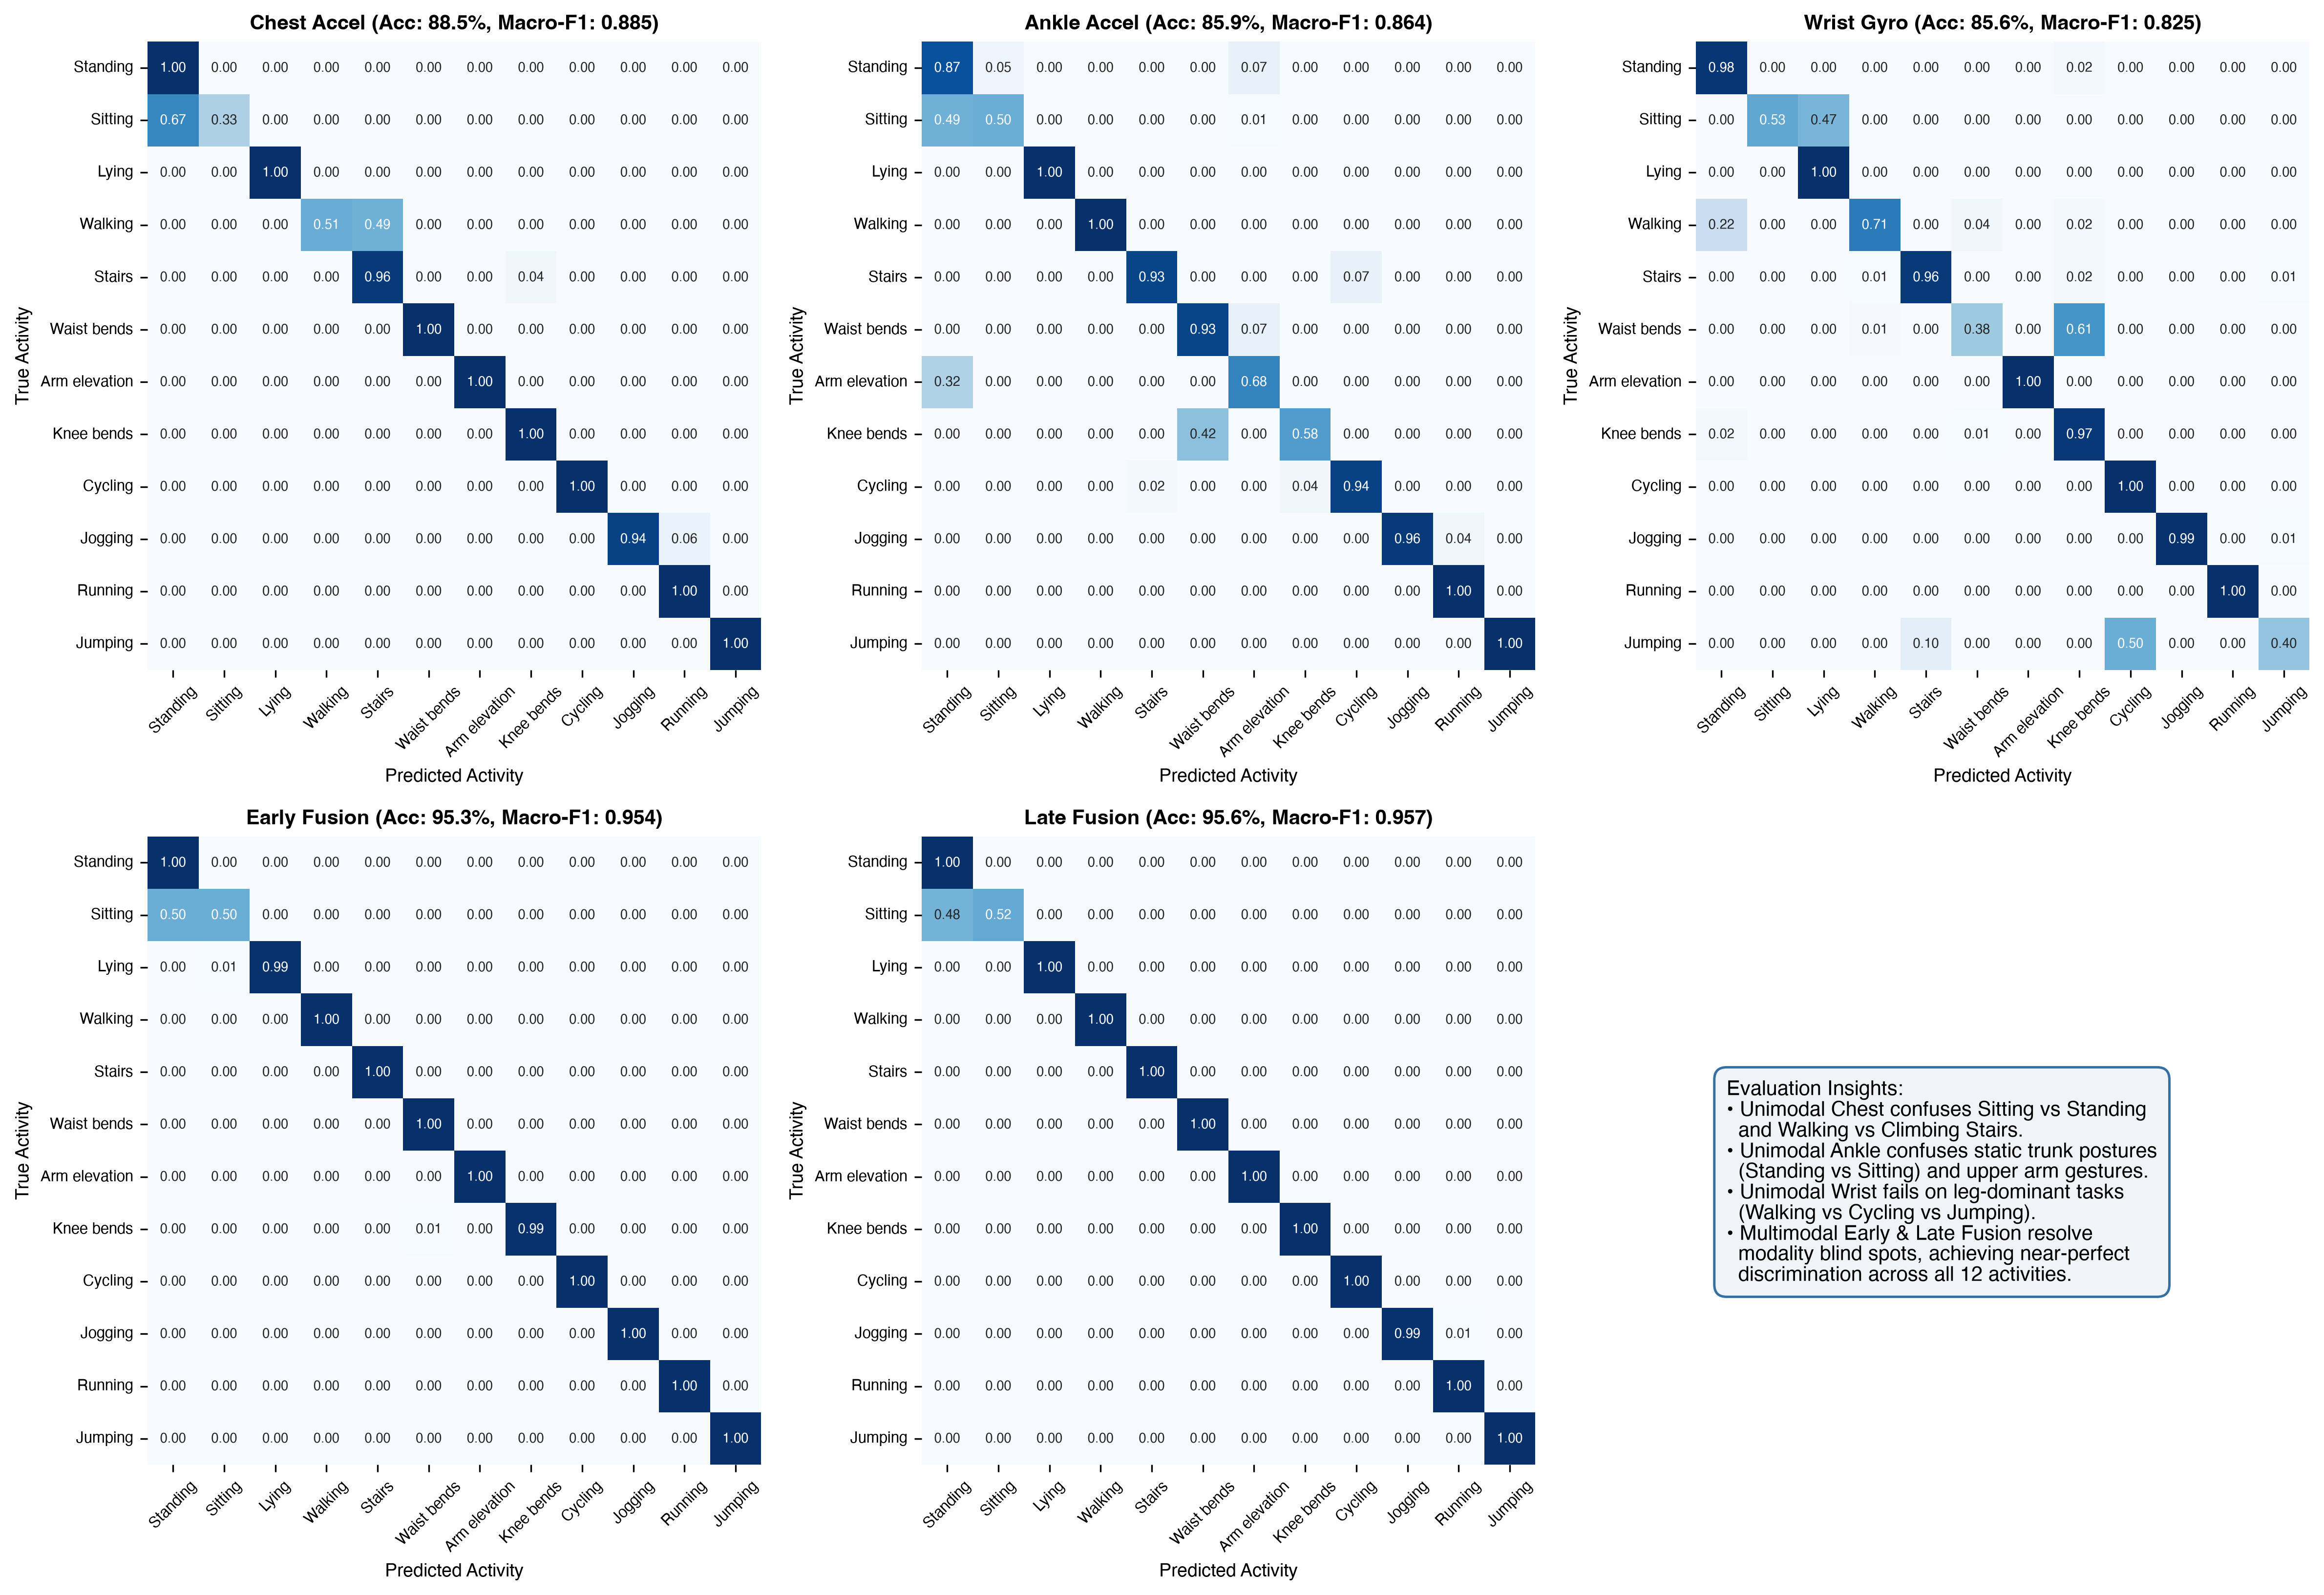

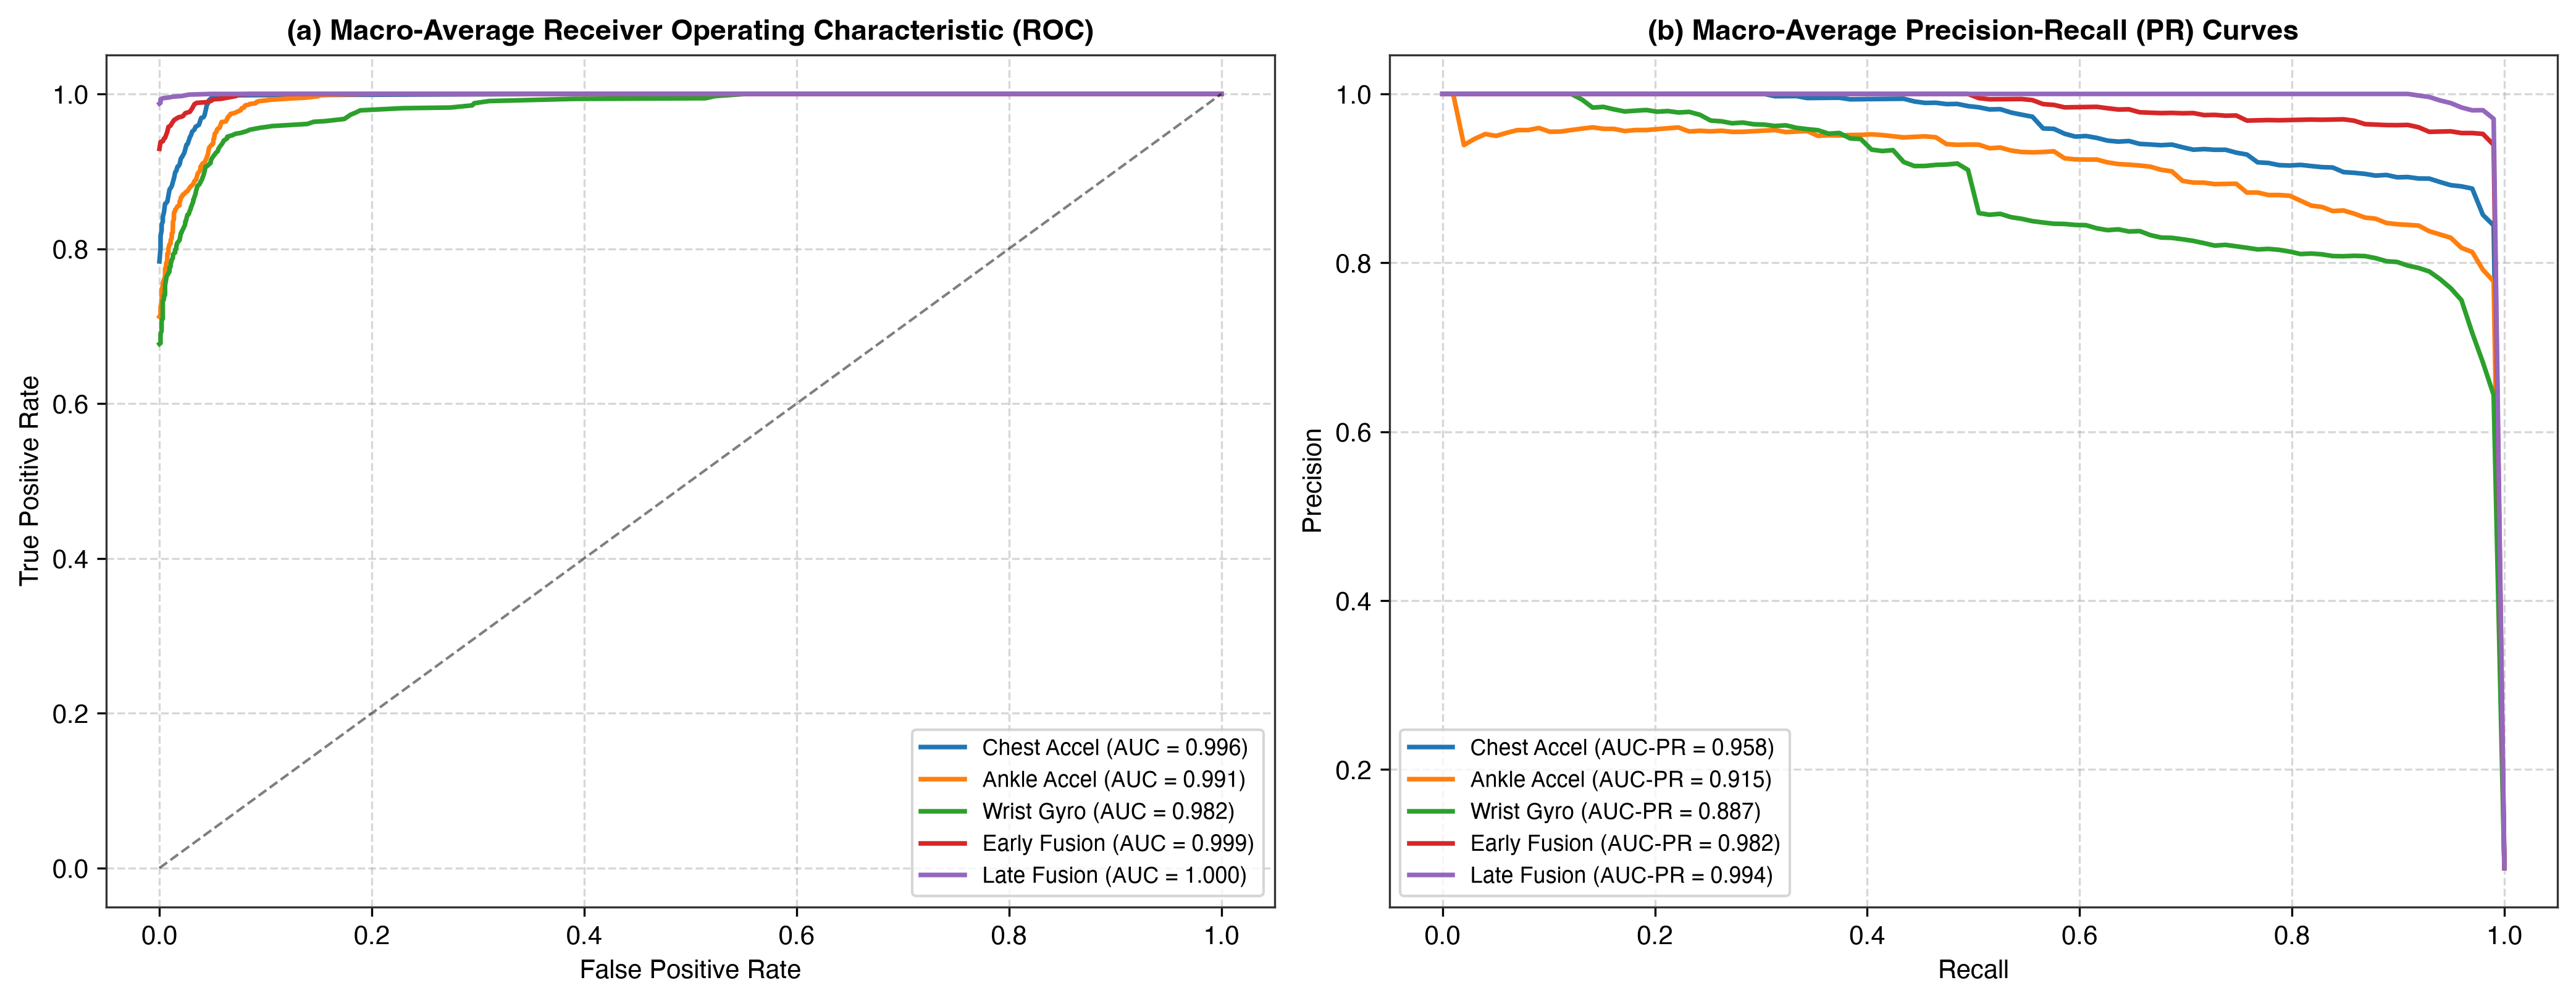

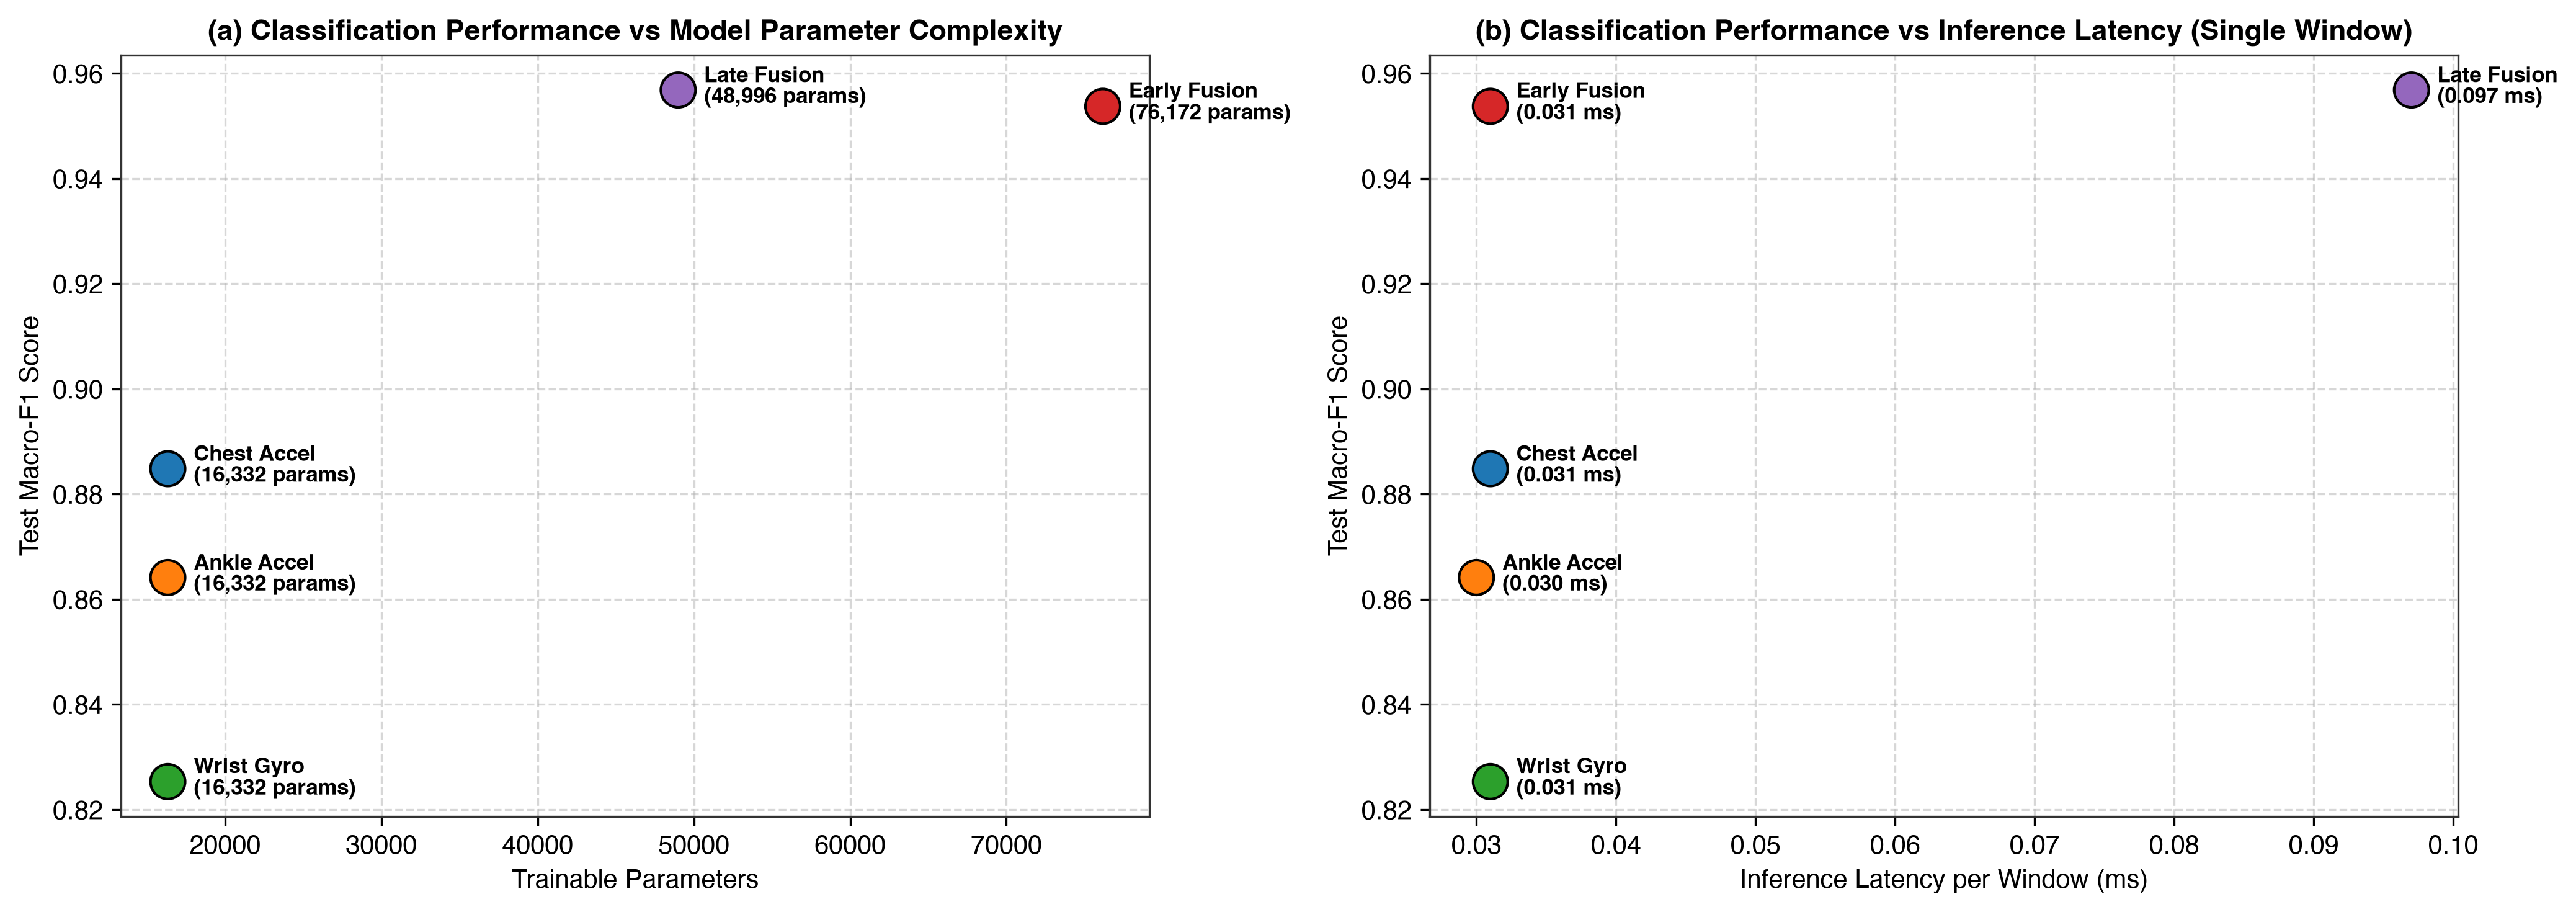

In [7]:
from IPython.display import Image, display

display(Image(filename='figures/fig6_confusion_matrices.png'))
display(Image(filename='figures/fig7_roc_pr_curves.png'))
display(Image(filename='figures/fig8_computational_tradeoffs.png'))
